# Section: Determining a Velocity Model For Utopia Planitita

This notebook shows how we derive velocity model from the preprocessed Utopia Planitia gpr data. Manual annotations done twice, c3 and auto hyperbola fit done once. I omit any explainations or walkthrough of these methods as they're covered previously in the paper and under different sections. This notebook should just be applying the mothods and getting data.

# Import our in-house package and dependencies
Should install relevant dependencies if there is a conflict

In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from pds4_tools.reader.core import pds4_read
from tqdm import tqdm

sys.path.append('../..')

import RoPeR
from RoPeR import bandpass, bgr, energy_eq, gain, prestitch
import SimulatingGPR.gprsim as gprsim
import Sections.hyperbola_fitting_to_estimate.gpr_c3_clustering

/Users/coltenrodriguez/anaconda3/lib/python3.10/site-packages/bruges/__init__.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


## Need to check out the data to get reelvant constants, but we can ompit all the preprocessing

In [3]:
'''
Retrieving files and sorting them
'''
n, m = 0, 109 # 0-109, load all 109 files
data_dir = '/Users/coltenrodriguez/Desktop/Senior_Thesis/RoPeR_LF' # were data

In [4]:
files = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if '.2CL' in f]
files = sorted(files, key=lambda f: int(f[-10:-6]))[n:m]
length = len(files)

sample_depth = {6000:15000, 4000:10000, 2000:5000, 1000:2500} # number of total pixels in either R/I data: nanoseconds penetration
observable_depth_ns = 1200 # Arbitaraty value

In [5]:
from collections import Counter, defaultdict
'''
Check inhomogenous data (e.g. not all files are LF). also get the effective data legnth (to get ns/px)
'''

effective_data_lens = [info[8] for info in [pds4_read(file, quiet=True)[0].data[0] for file in files]] # Just take the metadata associated with the first trace, as each trace in each file will be the same


if len(set(effective_data_lens)) == 1:
    print(f"Input data is homogenous. Effective data length is {effective_data_lens[0]} bytes. \n {effective_data_lens[0]/8} fpn for real data -- {(effective_data_lens[0]/8)/sample_depth[effective_data_lens[0]/8]} px/ns")
    half_length = int(effective_data_lens[0]/8)
    px_per_ns = half_length/sample_depth[effective_data_lens[0]/8]
else:
    print("Inhomogenous data types. Check that all files are LF or have the same effective data length")

Input data is homogenous. Effective data length is 48000 bytes. 
 6000.0 fpn for real data -- 0.4 px/ns


In [6]:
remove_air = 0
'''
Stitching multiple data files together and gathering some preprocessing data for each file
'''
phase = [0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
pixel_distances = []
sample_meta = None
for f, i, j in zip(files, range(0, length), tqdm(range(length-1))): 
    if n<=i<=m:
        fdata = pds4_read(f, quiet=True)[0].data
        if len(set([int.from_bytes(d[6], 'big', signed=False) for d in fdata])) > 1:
            raise Exception("Trigger mode is not homogenously fixed_distance")
        sample_meta = fdata[0] # might be useless
        scan2d = np.array([d[9] for d in fdata])
        real_part_scan2d = np.array(scan2d[:, :half_length]).T[remove_air:, :]
        
        sample_depth_px, real_part_scan2d_depth_adj = prestitch.depth_correction(real_part_scan2d, px_per_ns, observable_depth_ns)
        real_part_scan2d_depth_self_adj, sds = prestitch.remove_self_detection(real_part_scan2d_depth_adj)
        sds = prestitch.phase_correction(sds, phase[i])
        real_part_scan2d_depth_self_phase_adj = prestitch.phase_correction(real_part_scan2d_depth_self_adj, phase[i])
        real_part_scan2d_depth_self_phase_bgr_adj, _ = bgr.remove_bg(real_part_scan2d_depth_self_phase_adj)
        # Assume this is all interpreted
        yaw = np.array([d[23] for d in fdata])
        pos_x = np.array([d[19] for d in fdata])
        pos_y = np.array([d[20] for d in fdata])
        pos_z = np.array([d[21] for d in fdata])
        pixel_distances.append(np.array([int.from_bytes(d[7], 'big', signed=False) for d in fdata])*10e-3)
        if i == n:
            raw = real_part_scan2d_depth_adj
            self_detection = real_part_scan2d_depth_self_adj
            phase_offset = real_part_scan2d_depth_self_phase_adj
            phase_offset_bg = real_part_scan2d_depth_self_phase_bgr_adj
            self_detections = np.array(sds)
            yaws = yaw
            poss_x, poss_y, poss_z = pos_x, pos_y, pos_z
            trace_dist_m = np.sum(np.array([int.from_bytes(d[7], 'big', signed=False) for d in fdata])*10e-3) # Fixed dist trigger is not fixed for all scans, record dist in a way that pulls from the .CL
        else:
            raw = np.concatenate((raw, real_part_scan2d_depth_adj), axis=1)
            self_detection = np.concatenate((self_detection, real_part_scan2d_depth_self_adj), axis=1)
            phase_offset = np.concatenate((phase_offset, real_part_scan2d_depth_self_phase_adj), axis=1)
            phase_offset_bg = np.concatenate((phase_offset_bg, real_part_scan2d_depth_self_phase_bgr_adj), axis=1)
            self_detections = np.concatenate((self_detections, sds), axis=1)
            yaws = np.concatenate((yaws, yaw))
            poss_x, poss_y, poss_z = np.concatenate((poss_x, pos_x)), np.concatenate((poss_y, pos_y)), np.concatenate((poss_z, pos_z))
            trace_dist_m+=np.sum(np.array([int.from_bytes(d[7], 'big', signed=False) for d in fdata])*10e-3)
            

100%|████████████████████████████████████████████████████████████████████████████████████| 107/107 [00:14<00:00,  7.28it/s]


In [7]:
# load the preprocessed data
p = np.load('/Users/coltenrodriguez/Desktop/GPR-modeling/Sections/determining_a_velocity_model/preprocessed_data.npy')


# Generate a velocity model for the subsurface

We have preprocessed the data and it was so easy! (it wasnt). Now we can finally begin doing what is literally everyone else's first step in GPR processing!

Li et. al. go to 1200ns. I personally have a hard time trusting data at 171m. Even for dry sand and gravel at such low frequency, everyone I've talked to wouldn't expect >100m. Even the IDed dipping reflectors weren't bellow 20m. I think we strike a good balance restricting ourselves to the upper 80m, which, for the absolute lowest eps_r, should be around 800-1000ns.

In [8]:
def meters_to_pixels(meter_interval, pixel_distances):
    start_m, end_m = meter_interval

    # cumulative distance to the start of each pixel
    cumulative_m = np.concatenate(([0], np.cumsum(pixel_distances)))

    # find pixel indices
    start_pixel = np.searchsorted(cumulative_m, start_m, side="left")
    end_pixel = np.searchsorted(cumulative_m, end_m, side="right") - 1

    # clamp to valid range
    start_pixel = max(0, min(start_pixel, len(pixel_distances) - 1))
    end_pixel = max(0, min(end_pixel, len(pixel_distances) - 1))

    return start_pixel, end_pixel
    
def norm2d(array):
    min_val = np.min(array)
    max_val = np.max(array)
    
    # Apply the normalization formula
    normalized_array = 2 * ((array - min_val) / (max_val - min_val)) - 1
    
    return normalized_array

def zoom(array, bounds):
    # Bounds in [left, right, bottom, top]
    # [:, :], Col slice (vertical), rows slice (horiz), row slice should be left:right, byut col slice should be bottom:top
    '''
    Bounds should be specified as:

                Left: Left coordinate (in meters)
                Right: Right coord (in meters)
                Top: stratigraphic bottom, the larger twt (in ns)
                Bottom: stratigraphic top, the smaller twt (in ns)

    This way bounds may be passed as an arg to plt without modification to show true (phyiscal) position 
    '''
    left, right = meters_to_pixels((bounds[0], bounds[1]), np.concatenate(pixel_distances).ravel())
    return array[int(bounds[3]*0.4):int(bounds[2]*0.4), left:right], bounds
    

In [10]:
min_x, max_x = 0, 100
min_t, max_t = 0, 700
array, bounds = zoom(p, [min_x, max_x, max_t, min_t])
cmap = plt.get_cmap('seismic')
rgb_img = cmap(array)[:,:,0]
fig = plt.figure(figsize=(6,4))
plt.imshow(array, cmap="seismic")

## 5.2 Hyperbola fitting, more options
1. manually anotate to get hyperbolae -- This easy and pretty reliable, but I've always said, why do something the easy way when you can spend 2 months learning and coding a worse solution? -->
2. C3!! This is the **preeminent** hyperbola anotating algorithm. Unfortuantely, in most cases, our data is so noisy (in ways that we couldn't remove using standard -- not overkill -- signal processing) that this doesn't work. I'll use a combination of both. The hyperbola are subtle in this data, not nearly as perfect as the contrived examples in the c3 paper so this is expected.

### 5.2.1 User Discretion -- Classic Manual Hyperbola Drawing

In [11]:
"""
GPR Hyperbola Picker
====================
Fit hyperbolae to hand-picked points on a radargram to estimate
dielectric permittivity and reflector position.

Usage
-----
    results = run_picker(radargram, px_per_m, px_per_ns, bounds)

Parameters
----------
radargram   : 2-D numpy array  (rows = time, cols = distance)
px_per_m    : float  — horizontal pixels per metre
px_per_ns   : float  — vertical pixels per nanosecond
bounds      : (int, int) — (left, right) pixel indices of this slice
              within the full radargram (used to report absolute coords)

Returns
-------
results : list of dicts, one per fitted hyperbola:
    {
        'permittivity' : float,
        'apex_x_px'   : float,   # in full-radargram pixel coords
        'apex_t_ns'   : float,   # apex two-way travel time (ns)
        'velocity_m_ns': float,
    }
"""

import tkinter as tk
from tkinter import ttk
import numpy as np
from scipy.optimize import curve_fit
import matplotlib
matplotlib.use("TkAgg")
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import matplotlib.pyplot as plt

C_M_PER_NS = 0.299792458   # speed of light in m/ns


# ---------------------------------------------------------------------------
# Physics helpers
# ---------------------------------------------------------------------------

def hyperbola_t(x_px, x0_px, t0_ns, v_m_ns, px_per_m, px_per_ns):
    """Two-way travel time (in pixels) for a point reflector hyperbola."""
    x_m  = (x_px - x0_px) / px_per_m          # offset from apex (m)
    t_ns = np.sqrt(t0_ns**2 + (2 * x_m / v_m_ns)**2)
    return t_ns * px_per_ns                    # convert back to pixels


def fit_hyperbola(points_px, px_per_m, px_per_ns):
    """
    Fit a hyperbola to ≥3 (x, t) pixel coordinates.

    Returns (x0_px, t0_ns, v_m_ns, permittivity) or raises RuntimeError.
    """
    xs = np.array([p[0] for p in points_px], dtype=float)
    ts = np.array([p[1] for p in points_px], dtype=float)

    # Initial guess: apex at the shallowest point
    idx0   = np.argmin(ts)
    x0_g   = xs[idx0]
    t0_g   = ts[idx0] / px_per_ns             # ns
    v_g    = 0.1                               # m/ns  (er ≈ 9)

    def model(x_px, x0_px, t0_ns, v_m_ns):
        return hyperbola_t(x_px, x0_px, t0_ns, v_m_ns, px_per_m, px_per_ns)

    bounds_lo = [xs.min() - 50, 0,    0.01]
    bounds_hi = [xs.max() + 50, 1e4,  C_M_PER_NS]

    popt, _ = curve_fit(
        model, xs, ts,
        p0=[x0_g, t0_g, v_g],
        bounds=(bounds_lo, bounds_hi),
        maxfev=10000,
    )
    x0_px, t0_ns, v_m_ns = popt
    er = (C_M_PER_NS / v_m_ns) ** 2
    return x0_px, t0_ns, v_m_ns, er


# ---------------------------------------------------------------------------
# Main application
# ---------------------------------------------------------------------------

class HyperbolaPicker:
    POINT_RADIUS = 5
    COLORS = ["#e63946", "#2a9d8f", "#e9c46a", "#f4a261", "#264653"]

    def __init__(self, root, radargram, px_per_m, px_per_ns, bounds):
        self.root       = root
        self.radargram  = radargram
        self.px_per_m   = px_per_m
        self.px_per_ns  = px_per_ns
        self.bounds     = bounds          # (left_px, right_px) in full image
        self.results    = []

        self._pending_points = []         # clicks for current hyperbola
        self._hyperbola_idx  = 0
        self._artists        = []         # (scatter, line) per hyperbola

        root.title("GPR Hyperbola Picker")
        self._build_ui()

    # ------------------------------------------------------------------
    # UI construction
    # ------------------------------------------------------------------

    def _build_ui(self):
        root = self.root

        # ── top instruction bar ──────────────────────────────────────
        info_frame = tk.Frame(root, bg="#1e1e2e", pady=6)
        info_frame.pack(fill=tk.X)
        self._status = tk.StringVar(value="Click 3 points on a hyperbola, then press Fit.")
        tk.Label(
            info_frame, textvariable=self._status,
            bg="#1e1e2e", fg="#cdd6f4", font=("Helvetica", 11)
        ).pack(side=tk.LEFT, padx=12)

        # ── matplotlib figure ────────────────────────────────────────
        nrows, ncols = self.radargram.shape
        fig_w = min(15, max(6, ncols / 60))
        fig_h = min(12,  max(4, nrows / 60))
        self.fig, self.ax = plt.subplots(figsize=(fig_w, fig_h), tight_layout=True)
        self._draw_radargram()

        self.canvas = FigureCanvasTkAgg(self.fig, master=root)
        self.canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)
        self.canvas.mpl_connect("button_press_event", self._on_click)

        # ── bottom controls ──────────────────────────────────────────
        ctrl = tk.Frame(root, bg="#181825", pady=6)
        ctrl.pack(fill=tk.X)

        btn_style = dict(bg="#313244", fg="#cdd6f4",
                         activebackground="#45475a", activeforeground="#cdd6f4",
                         relief=tk.FLAT, padx=14, pady=4, font=("Helvetica", 10))

        tk.Button(ctrl, text="Fit hyperbola",  command=self._fit,   **btn_style).pack(side=tk.LEFT,  padx=8)
        tk.Button(ctrl, text="Clear last",     command=self._clear_last, **btn_style).pack(side=tk.LEFT, padx=4)
        tk.Button(ctrl, text="Clear all",      command=self._clear_all,  **btn_style).pack(side=tk.LEFT, padx=4)
        tk.Button(ctrl, text="Done / close",   command=self._done,  **btn_style).pack(side=tk.RIGHT, padx=8)

        # ── results table ────────────────────────────────────────────
        tbl_frame = tk.Frame(root, bg="#181825")
        tbl_frame.pack(fill=tk.X, padx=8, pady=(0, 6))

        cols = ("Hyperbola", "εr", "v (m/ns)", "Apex x (px, full)", "Apex t (ns)")
        self.table = ttk.Treeview(tbl_frame, columns=cols, show="headings", height=4)
        for c in cols:
            self.table.heading(c, text=c)
            self.table.column(c, width=140, anchor=tk.CENTER)
        self.table.pack(fill=tk.X)

        style = ttk.Style()
        style.theme_use("clam")
        style.configure("Treeview",
                         background="#1e1e2e", foreground="#cdd6f4",
                         fieldbackground="#1e1e2e", rowheight=22)
        style.configure("Treeview.Heading",
                         background="#313244", foreground="#cdd6f4")

    # ------------------------------------------------------------------
    # Radargram rendering
    # ------------------------------------------------------------------

    def _draw_radargram(self):
        ax  = self.ax
        rg  = self.radargram
        nrows, ncols = rg.shape

        vmax = np.percentile(np.abs(rg), 98) or 1.0
        ax.imshow(rg, cmap="seismic",
                  aspect="auto", interpolation="nearest",
                  extent=[0, ncols, nrows, 0])

        # axis labels in physical units
        xticks_px  = np.linspace(0, ncols, 6)
        xticks_m   = (xticks_px / self.px_per_m)
        ax.set_xticks(xticks_px)
        ax.set_xticklabels([f"{v:.1f}" for v in xticks_m], color="#cdd6f4")

        yticks_px  = np.linspace(0, nrows, 6)
        yticks_ns  = yticks_px / self.px_per_ns
        ax.set_yticks(yticks_px)
        ax.set_yticklabels([f"{v:.0f}" for v in yticks_ns], color="#cdd6f4")

        ax.set_xlabel("Distance (m)", color="#cdd6f4")
        ax.set_ylabel("Two-way travel time (ns)", color="#cdd6f4")
        ax.tick_params(colors="#cdd6f4")
        for spine in ax.spines.values():
            spine.set_edgecolor("#45475a")
        self.fig.patch.set_facecolor("#1e1e2e")
        ax.set_facecolor("#1e1e2e")

        # lock limits so hyperbola overlays never expand the axes
        self._xlim = (0, ncols)
        self._ylim = (nrows, 0)
        ax.set_xlim(*self._xlim)
        ax.set_ylim(*self._ylim)

    # ------------------------------------------------------------------
    # Event handlers
    # ------------------------------------------------------------------

    def _on_click(self, event):
        if event.inaxes != self.ax:
            return
        if event.button != 1:
            return
        x, t = event.xdata, event.ydata
        self._pending_points.append((x, t))
        n = len(self._pending_points)

        color = self.COLORS[self._hyperbola_idx % len(self.COLORS)]
        self.ax.plot(x, t, "o", color=color, markersize=self.POINT_RADIUS,
                     zorder=5)
        self.canvas.draw_idle()

        if n < 3:
            self._status.set(f"Point {n}/3 placed — click {3 - n} more.")
        else:
            self._status.set("3 points placed. Press 'Fit hyperbola' or add more for a better fit.")

    def _fit(self):
        pts = self._pending_points
        if len(pts) < 3:
            self._status.set(f"Need at least 3 points — only {len(pts)} placed.")
            return

        try:
            x0_px, t0_ns, v_m_ns, er = fit_hyperbola(pts, self.px_per_m, self.px_per_ns)
        except Exception as exc:
            self._status.set(f"Fit failed: {exc}")
            return

        # convert apex x from slice-local pixels to full-image pixels
        left_bound    = self.bounds[0]
        apex_x_full   = left_bound + x0_px
        apex_t_ns     = t0_ns

        result = dict(
            permittivity  = er,
            apex_x_px     = apex_x_full,
            apex_t_ns     = apex_t_ns,
            velocity_m_ns = v_m_ns,
        )
        self.results.append(result)

        # ── console output ────────────────────────────────────────────
        idx = len(self.results)
        print(f"\n── Hyperbola {idx} ──────────────────────────")
        print(f"  Relative permittivity  εr  = {er:.3f}")
        print(f"  Wave velocity              = {v_m_ns:.4f} m/ns")
        print(f"  Apex x (full image, px)    = {apex_x_full:.1f}")
        print(f"  Apex two-way time          = {apex_t_ns:.2f} ns")
        print(f"  Apex depth (one-way)       = {v_m_ns * apex_t_ns / 2:.2f} m")

        # ── overlay fitted curve ──────────────────────────────────────
        nrows, ncols = self.radargram.shape
        x_range = np.linspace(0, ncols, 500)
        t_fit   = hyperbola_t(x_range, x0_px, t0_ns, v_m_ns,
                              self.px_per_m, self.px_per_ns)

        color = self.COLORS[(self._hyperbola_idx) % len(self.COLORS)]
        (line,) = self.ax.plot(x_range, t_fit, "-", color=color,
                               linewidth=1.8, zorder=4,
                               label=f"H{idx}  εr={er:.2f}")
        apex_dot, = self.ax.plot(x0_px, t0_ns * self.px_per_ns, "*",
                                 color=color, markersize=12, zorder=6)
        self.ax.legend(facecolor="#313244", labelcolor="#cdd6f4",
                       fontsize=9, loc="upper right")
        self.ax.set_xlim(*self._xlim)
        self.ax.set_ylim(*self._ylim)
        self._artists.append((line, apex_dot))
        self.canvas.draw_idle()

        # ── results table ─────────────────────────────────────────────
        self.table.insert("", tk.END, values=(
            f"H{idx}",
            f"{er:.3f}",
            f"{v_m_ns:.4f}",
            f"{apex_x_full:.1f}",
            f"{apex_t_ns:.2f}",
        ))

        # reset for next hyperbola
        self._pending_points = []
        self._hyperbola_idx += 1
        self._status.set(f"Hyperbola {idx} fitted (εr={er:.2f}). Click 3+ points for the next one.")

    def _clear_last(self):
        """Remove pending (unfitted) points."""
        self._pending_points = []
        # redraw to drop dangling point markers
        self.ax.cla()
        self._draw_radargram()
        # re-draw all accepted hyperbolas
        for i, (line, apex) in enumerate(self._artists):
            color = self.COLORS[i % len(self.COLORS)]
            self.ax.add_line(
                matplotlib.lines.Line2D(line.get_xdata(), line.get_ydata(),
                                        color=color, linewidth=1.8)
            )
            self.ax.plot(*apex.get_data(), "*", color=color, markersize=12, zorder=6)
        self.ax.set_xlim(*self._xlim)
        self.ax.set_ylim(*self._ylim)
        self.canvas.draw_idle()
        self._status.set("Pending points cleared. Click to start again.")

    def _clear_all(self):
        self._pending_points = []
        self._artists        = []
        self._hyperbola_idx  = 0
        self.results         = []
        self.table.delete(*self.table.get_children())
        self.ax.cla()
        self._draw_radargram()
        self.canvas.draw_idle()
        self._status.set("All cleared. Click 3 points on a hyperbola.")

    def _done(self):
        self.root.quit()
        self.root.destroy()


# ---------------------------------------------------------------------------
# Public entry point
# ---------------------------------------------------------------------------

def run_picker(radargram, px_per_m, px_per_ns, bounds):
    """
    Launch the picker GUI and return collected results when the window closes.

    Parameters
    ----------
    radargram  : 2-D numpy array
    px_per_m   : horizontal pixels per metre
    px_per_ns  : vertical pixels per nanosecond
    bounds     : (left_px, right_px) of this slice in the full image

    Returns
    -------
    list of dicts  (one per fitted hyperbola)
    """
    root = tk.Tk()
    app  = HyperbolaPicker(root, radargram, px_per_m, px_per_ns, bounds)
    root.mainloop()
    return app.results


# ---------------------------------------------------------------------------
# Quick demo (synthetic data)
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    # ── synthetic radargram with two point-reflector hyperbolae ──────
    px_per_m  = 2    # 0.5 m / pixel horizontally
    px_per_ns = 1/2.5   # 1 ns / pixel vertically
    bounds    = (5662, 6262)   # this slice starts at pixel 50 in the full image

    rg = array

    print("GPR Hyperbola Picker — demo mode")
    print("Click 3+ points on each hyperbola, press 'Fit hyperbola', then 'Done'.\n")

    results = run_picker(rg, px_per_m, px_per_ns, bounds)

    print("\n══ Final results ══════════════════════════════")
    for i, r in enumerate(results, 1):
        print(f"  Hyperbola {i}: εr={r['permittivity']:.3f}  "
              f"apex_x={r['apex_x_px']:.1f} px (full)  "
              f"apex_t={r['apex_t_ns']:.2f} ns  "
              f"v={r['velocity_m_ns']:.4f} m/ns")
        points.append((r['apex_x_px'], r['apex_t_ns'], r['permittivity']))


GPR Hyperbola Picker — demo mode
Click 3+ points on each hyperbola, press 'Fit hyperbola', then 'Done'.



/var/folders/vv/wqjks1114hz5w6vtzybkd8gc0000gn/T/ipykernel_53217/2128021580.py:74: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(



── Hyperbola 1 ──────────────────────────
  Relative permittivity  εr  = 8.879
  Wave velocity              = 0.1006 m/ns
  Apex x (full image, px)    = 5812.5
  Apex two-way time          = 378.71 ns
  Apex depth (one-way)       = 19.05 m

══ Final results ══════════════════════════════
  Hyperbola 1: εr=8.879  apex_x=5812.5 px (full)  apex_t=378.71 ns  v=0.1006 m/ns


NameError: name 'points' is not defined

## Selecting a region to look ar hyperbolae
min_x, max_x are in units of meters --- the conversion to pixels and heterogeneous dx is all handled by the zoom function
min_t and max_t are in units of ns

(280, 200)

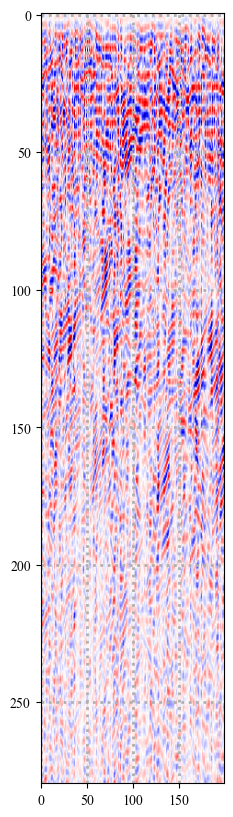

In [308]:
min_x, max_x = 0, 100
min_t, max_t = 0, 700
array, bounds = zoom(p, [min_x, max_x, max_t, min_t])
cmap = plt.get_cmap('seismic')
rgb_img = cmap(array)[:,:,0]
plt.imshow(array, cmap="seismic", aspect=3)
array.shape

## Two runs of manual fitting
An array of tuples of size 3 of the format (apex horizontal position in pixels, apex vertical position in pixels, epsilon)
1. Sparse sampling. Only pick the best, most obvious hyperbolae
2. Dense sampling. Look really hard --> downside: are we immagining a hyperbola when it really isn't one?


In [12]:
points = [(96.21394932641245, 91.73817117718771, 3.1872020277389037),
 (149.19080512199483, 369.71848943317167, 4.907899555727503),
 (307.4408307018802, 122.3275818939788, 3.6698151282688443),
 (283.9298515104694, 352.2602674634739, 5.255000130768836),
 (227.9836089537263, 677.9700427994271, 7.922592317504873),
 (328.23046858290627, 94.102878474549, 3.478741217468942),
 (727.8444096375603, 209.64829063583068, 4.324002261775977),
 (684.232460618321, 28.71286200484331, 3.5497183665294707),
 (624.5684174418653, 670.5868347369592, 7.9256683402988655),
 (971.7456201170642, 56.98216018313612, 3.025878278530732),
 (972.122251898162, 350.1770831319845, 5.133235183458932),
 (1354.0067415528633, 92.66443819337113, 3.791985932870023),
 (1275.1884363123822, 259.96865668628556, 6.3687683416799),
 (1244.9926537866354, 661.7117002860585, 6.896619252804621),
 (1542.8126267197647, 23.291685597646236, 3.1019171069162215),
 (1708.3996735877636, 142.46850398276558, 4.2433382921102325),
 (1498.0110653913334, 571.0033814631065, 4.4562669304473985),
 (2046.7733387670914, 146.14362192130372, 4.281202587245392),
 (1797.8401924432562, 557.346126362376, 6.4123731044143994),
 (2518.9493555669396, 214.34553028079847, 4.676851237153585),
 (2773.249378244265, 513.9931179523248, 5.169562954881795),
 (2673.3336670751023, 499.8173719357162, 5.5624850781136255),
 (2821.393637856055, 72.59710090645213, 2.477577833148144),
 (3411.927721357713, 434.0010991450636, 4.107319494627982),
 (3684.5408365204553, 557.1789713165233, 5.676208365910404),
 (3484.0231965855737, 125.6143874327697, 3.3843664864546845),
 (3519.2516796944687, 35.03555389011689, 2.8073482442105275),
 (4458.408757394646, 285.3816373218993, 4.366778198261907),
 (4715.821951463763, 629.8952560871318, 6.804735106307456),
 (4904.862066198007, 274.10158673701915, 3.447154433442401),
 (5359.861757710611, 228.46838737720657, 3.8610092673353877),
 (6029.834708221511, 112.23058899656536, 3.1028485798092102),
 (6010.460517863255, 250.28853571827895, 3.3655711610908106),
 (5730.907925409929, 654.7662295632847, 7.34100192907199)]

In [11]:
points = [(96.25264000096631, 88.09730933093043, 3.601920446851148),
 (14.282982021063622, 225.6621156733321, 12.617264790746653),
 (96.9984794144397, 77.05081339048611, 3.3138074346164976),
 (9.36377607328773, 199.14155993646565, 6.850902910496019),
 (97.02668912309929, 75.52149062096203, 2.455621851366253),
 (10.93781859454154, 516.5717479086048, 13.433716930138033),
 (67.71462804522766, 343.4835086750948, 9.846193042625393),
 (104.28085111796771, 223.95297669679871, 4.884729138930903),
 (148.99162094342694, 357.03995371411804, 5.269297780086825),
 (95.52372653659805, 520.5589823938056, 9.215775985369836),
 (123.5845493960752, 649.3383815583854, 7.690592986897978),
 (393.40619123372664, 118.22302542129398, 6.6022548721425),
 (306.13887683253995, 111.41332695211194, 4.3497333945461705),
 (236.79631304489573, 227.20793236147423, 7.66791344945864),
 (269.8524802596654, 269.9305580505903, 5.383169015125586),
 (392.8410667526471, 403.39516814574785, 13.247055971595922),
 (266.5504802970628, 515.5534974323087, 7.8014831920868595),
 (346.1274944489204, 550.6469906352, 13.632986974281623),
 (258.58090750827137, 65.89536318345225, 2.7619800192849735),
 (331.67956027961077, 301.80028300099264, 10.060940983671095),
 (435.6557457499814, 124.46193769811255, 3.809476983041193),
 (534.479596320545, 154.89367146324486, 5.224403936579874),
 (483.2983411739034, 339.22139810639817, 7.6099064419357765),
 (501.3545404344769, 660.7425826477989, 17.533368502450895),
 (582.3162773470408, 660.8021864581974, 13.266136905475689),
 (468.1538786279177, 480.20796995179904, 11.819726489302333),
 (549.8711518092008, 418.7088060576368, 13.733178378893438),
 (685.0689241613967, 19.93362383605323, 4.011911541809092),
 (726.5796846960064, 194.3599160045322, 3.3941092179562413),
 (792.0446655542718, 536.4316168261423, 15.600118236578494),
 (676.0955130701161, 230.25696190594556, 4.786653902838898),
 (622.4133129027142, 134.94077445554035, 3.6302828756458507),
 (645.5086572912495, 142.69161709341066, 3.6355596025861963),
 (620.0105334666802, 371.1346901291868, 6.857709239026504),
 (658.8019347319355, 564.2827046435881, 16.63324812773289),
 (684.8025880187232, 23.851038057258105, 4.737488198784883),
 (728.9407483323862, 188.8420516534833, 4.645108443275584),
 (621.6346888762647, 135.12218487599603, 4.485584180515577),
 (645.2100791115597, 139.17242463890832, 5.792992696390306),
 (790.579728056335, 537.6023183901071, 14.951053738977718),
 (626.2765568374439, 613.8835302442246, 16.288074991725807),
 (672.663038093921, 210.6090414491346, 6.0110962462373125),
 (742.6762634392992, 359.74622196605577, 5.813658461929212),
 (973.7013168133712, 344.8089271238523, 7.926414328611979),
 (897.182834659748, 419.3592188399312, 16.189710563879178),
 (879.5048684101961, 84.23679392691255, 3.419201762152601),
 (1107.7541449084936, 197.1917439752604, 8.648421711066067),
 (1047.756523442871, 241.37608649536494, 7.107594677067271),
 (1172.9835065663365, 98.50912150599152, 8.045027316889103),
 (1015.9524576623329, 614.4964755924138, 12.342302431926136),
 (1090.0205435546725, 355.07375820788826, 13.550929470119806),
 (1011.738809227303, 160.07696076197774, 8.632995633282341),
 (1181.5603383175178, 487.79418169492794, 10.609582154050036),
 (1356.0136355098696, 73.81444330136628, 2.212271198053942),
 (1229.239098217751, 220.35329927281256, 6.344531662317339),
 (1214.800517875428, 49.34271733023202, 3.550206664591575),
 (1275.5413527042222, 247.42143922938834, 7.768030352141496),
 (1257.026520363103, 523.3332834570969, 13.559679455040198),
 (1340.3120700829083, 554.0285045218714, 10.445155695603765),
 (1544.2918652530573, 18.859936937633197, 3.0266368502561227),
 (1657.7316966541578, 211.1352345665634, 4.88370800204975),
 (1599.6756276416775, 46.21328330467313, 3.2745426503222657),
 (1604.1840306784845, 346.9230225265849, 9.344257871725425),
 (1428.8187601399675, 497.88440279373907, 6.9242168462127065),
 (1825.650153298214, 50.556580521874615, 2.73543957589768),
 (1882.2347003834361, 233.9931914832619, 5.788287455559036),
 (1917.4236908293408, 574.0722160397552, 16.209323089900344),
 (2101.3662503923765, 517.4706621130317, 16.713566530817722),
 (2084.685410299203, 131.79751802692041, 8.089086201143333),
 (2427.6756621938184, 76.66087650406446, 3.079630102483672),
 (2474.02190102032, 386.21503874895245, 8.74487347814469),
 (2617.6921322938783, 276.5603330766008, 7.034713834956734),
 (2338.43390087658, 124.40655281598512, 4.525159712256573),
 (2626.2182408542353, 448.99385244855137, 7.614117222337622),
 (2791.0709643512932, 391.34124146905054, 7.10053039647647),
 (2927.6707127764334, 263.0578292543951, 4.976362062393765),
 (2705.8865755249144, 103.2369495000351, 5.2580254037827086),
 (3410.5309381096313, 61.88968155031601, 3.4627112560808575),
 (3392.8268826783233, 341.90799266809495, 9.459707425503797),
 (3136.1230359154183, 267.65055766986893, 6.980622133569073),
 (3269.9643050348345, 268.5064076797663, 9.04585022918084),
 (3251.078709547567, 521.2490018116052, 7.421723497793909),
 (3220.6758185588224, 110.91024184403224, 4.832634866223348),
 (3649.6473410204444, 65.60957945203666, 4.548202075665809),
 (3686.663247415746, 561.3223823378094, 13.902826550984038),
 (3484.648421611587, 105.4943928995176, 7.78632989270399),
 (4051.5335312607394, 37.400835372874944, 2.0918716981128984),
 (4146.084478391284, 66.06491875959651, 2.248457861200175),
 (3886.469414281535, 238.7610134442159, 3.54055755555423),
 (4146.323286218734, 283.50645039586084, 7.2870672347780605),
 (4002.9930259926014, 678.8998685261992, 12.293313559852447),
 (4057.2970211836755, 272.700193131395, 8.812516417492395),
 (4500.21294633208, 25.903983872473095, 1.8594589843103593),
 (4499.536425826194, 24.685880324394493, 2.354335932359055),
 (4583.493025716343, 118.25849379149575, 2.5949286815908144),
 (4455.513413698839, 402.31734469083653, 6.658756556851471),
 (4463.403643100625, 650.6140444081965, 10.172464975100098),
 (4323.262487310153, 503.15851104628473, 15.679657411284099),
 (4976.68425753742, 21.12832089799824, 3.1846061111453863),
 (4771.242491720769, 28.18516133002169, 3.4618352407165816),
 (4955.82998100317, 372.3146107594496, 5.734198868601093),
 (4722.843648481252, 320.3568579975993, 6.7901000977702415),
 (4883.471948910884, 582.1199063720157, 6.613252224634112),
 (5611.9617677284305, 247.78906429050608, 6.767511605828111),
 (5320.2054496830515, 635.1635658453235, 9.778520661882926),
 (5389.229318264573, 161.48225983268694, 5.154383046208118),
 (5281.00752807183, 80.07135555627403, 3.03868284140473)]

## Interpolate data points to get velocity model

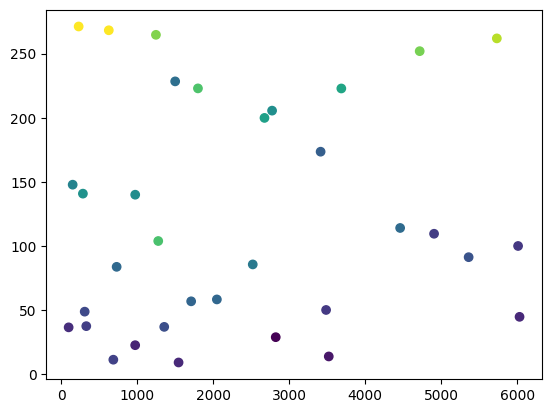

In [13]:
min_x, max_x = 0, 1800
min_t, max_t = 0, 700
array, bounds = zoom(p, [min_x, max_x, max_t, min_t])

# plt.imshow(rg, aspect='auto', cmap='seismic')
def norm(a):
    a = a - np.min(a)
    a/=(np.percentile(a,75)-np.percentile(a,25))
    return a
    
x = []
t = []
perm = []
for point in points:
    x.append(point[0])
    t.append(point[1]/2.5)
    perm.append(point[2])

perm = np.array(perm)
plt.scatter(x, t, c=perm)

(280, 5461)

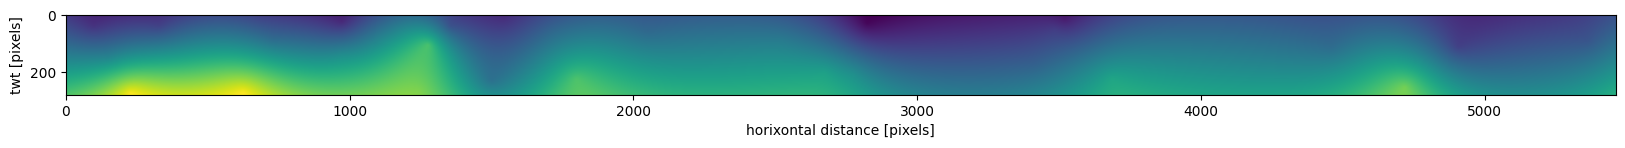

In [24]:
import numpy as np
from scipy.interpolate import griddata
from scipy.interpolate import Rbf

def interpolate_heatmap_rbf(image, xs, ys, values, function="linear"):
    h, w = image.shape
    grid_x, grid_y = np.meshgrid(np.arange(w), np.arange(h))

    rbf = Rbf(xs, ys, values, function=function)
    heatmap = rbf(grid_x, grid_y)

    return heatmap

image = np.zeros_like(array)

xs = x
ys = t
values = perm

heatmap = interpolate_heatmap_rbf(image, xs, ys, values)

# Visualization
fig = plt.figure(figsize=(20,10))
plt.imshow(heatmap)
plt.ylabel('twt [pixels]')
plt.xlabel("horixontal distance [pixels]")
np.save('/Users/coltenrodriguez/Desktop/GPR-modeling/Sections/RoPeR_migration/velocity_model.npy', heatmap)
heatmap.shape


# Method 2: Column Connection Clustering

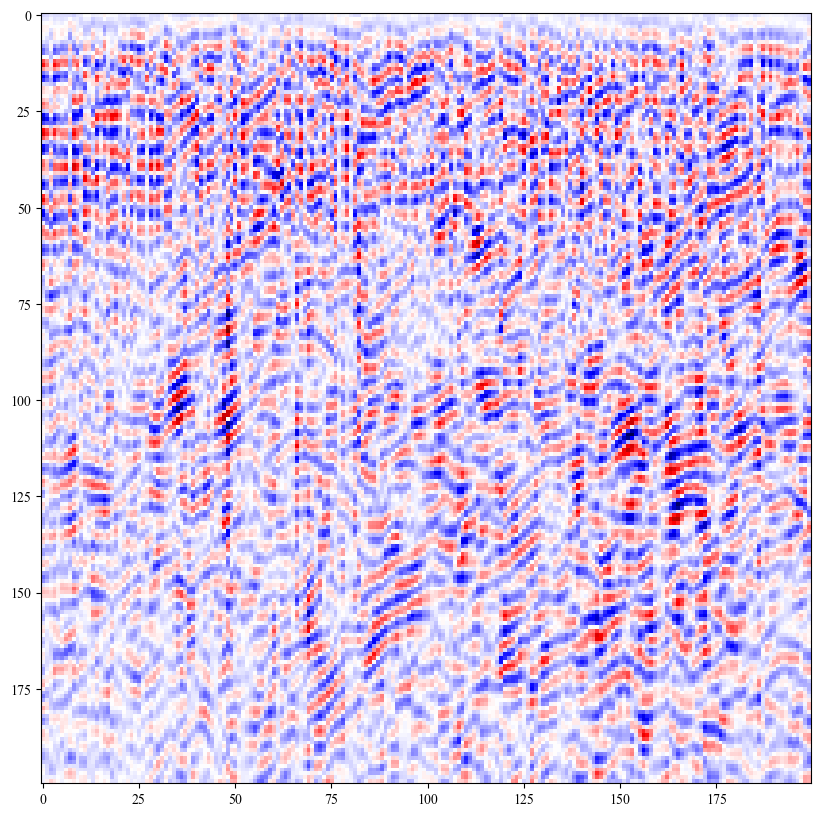

In [309]:
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'serif',  # Often a default in MATLAB
    'font.serif': ['Times New Roman'],
    'axes.labelsize': 15,
    'axes.titlesize': 20,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 1.5,
    'lines.marker': 'o',  # Example marker, adjust as needed
    'grid.linestyle': ':',
    'grid.linewidth': 2,
    'axes.grid': False,
    'figure.subplot.wspace': 0,  # Example: Increase horizontal spacing
    'figure.subplot.hspace': 0.3,  # Example: Increase vertical spacing
    'figure.figsize': (10, 10) # Adjust figure size
})

min_x, max_x = 100, 200
min_t, max_t = 0, 500
array, bounds = zoom(p, [min_x, max_x, max_t, min_t])
cmap = plt.get_cmap('seismic')
array = (array - np.mean(array))/np.std(array)
plt.imshow(array, cmap="seismic", aspect='equal')


In [14]:
from Sections.hyperbola_fitting_to_estimate import gpr_c3_clustering

bscan = array

clusters, binary = gpr_c3_clustering.c3_clustering(
    bscan,
    s=2,
    threshold = 0.3,
    rho_b=0.01,
    min_cluster_width=10,
    apply_derivative_split=True,
)

# print(f"Found {len(clusters)} clusters")
# for c in clusters:
#     pts = c.all_points
#     print(f"  Cluster {c.id}: {pts.shape[0]} points, "
#           f"columns {min(c.columns)}-{max(c.columns)}")

label_img = gpr_c3_clustering.cluster_label_image(clusters, bscan.shape)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(bscan, cmap="gray", aspect="auto")
axes[0].set_title("B-scan (synthetic)")
axes[1].imshow(binary, cmap="gray", aspect="auto")
axes[1].set_title("Binary (after thresholding)")
axes[2].imshow(label_img, cmap="tab20", aspect="auto")
# Overlay central strings
for c in clusters:
    cs = c.central_string
    if len(cs) > 1:
        axes[2].plot(cs[:, 1], cs[:, 0], "w-", linewidth=1)
axes[2].set_title("Cluster labels + central strings")
plt.tight_layout()

In [15]:
a = np.zeros_like(array)
for cluster in clusters:
    for col, row in cluster.columns.items():
        a[row, col] = 1

cmap = plt.cm.seismic
cmap.set_bad('black')
a =  np.ma.masked_where(~a.astype(bool), array)
plt.imshow(a, cmap=cmap)


In [16]:
import math
import warnings
fig = plt.figure(figsize=(10,10))

def hyperbola(x, v, x0, t0):
    y = np.sqrt(t0**2 + (np.abs(x-x0)/(v))**2)
    return y
    

for c in clusters:
        cs = c.central_string
        if len(cs) > 1:
            x = cs[:, 1]
            t = cs[:, 0]
            with warnings.catch_warnings(record=True) as w:
                warnings.simplefilter("error", RuntimeWarning)
                try:
                    v, x0, t0 = fit_hyperbola(bscan, 1, 'robust_fit', 0.5, 2.5, x, t)
                except RuntimeWarning as e:
                    continue
            #print((0.3/v)**2, x0, t0)
            if (not math.isnan((0.3/v)**2)) and (1 < (0.3/v)**2 < 10):
                # plot the hyperbolic template
                # plt.plot(x, hyperbola(x, v*2, x0*2, t0)/2.5, label=f'{(0.3/v)**2}', markersize=0)
                plt.plot(x, hyperbola(x, v*2, x0*2, t0)/2.5, label=f'{(0.3/v)**2}')
                print((0.3/v)**2)
            else:
                for col, row in c.columns.items():
                    a[row, col] = 0
a =  np.ma.masked_where(~a.astype(bool), array)
plt.imshow(array, cmap=cmap)
plt.legend()

TypeError: fit_hyperbola() takes 3 positional arguments but 7 were given

In [194]:
def fit_hyperbola(data, num_hyperbolas, method, dx, dt, x, t):

    if method=='robust_fit':
        # we want the physical coords of x, t
        x = x*dx # dx in meters per pixel meters
        t = t*dt # dt in **ns** per pixel        
        # Our linearized form of the hyperbola equation
        A = np.column_stack([x**2, -2*x, 1.0*np.ones_like(x)])
        b = t**2
        
        # solve with pseudoinverse -- do this twice to reduce outliers
        consts = np.linalg.pinv(A) @ b
        r = A@consts - b  
        sigma = 1.5 * np.median(np.abs(r - np.median(r))) # scale mad
        
        mask = np.abs(r) <= 0.5 * sigma
        consts2 = np.linalg.pinv(A[mask]) @ b[mask]
        alpha, beta, gamma = consts2
        
        if alpha == 'bad':
            print(Fore.RED + "Caught invalud value in sqrt: can not calculate hyperbola parameters from pinv. Switching to np.polyfit to avoid distruption. If np.polyfit quits, the input data may be too noisy")
            return fit_hyperbola(c, num_hyperbolas, 'fit_from_max', dx, dt, x, t)
        else:
            v = 1/np.sqrt(alpha)
            x0 = beta/alpha
            t0 = np.sqrt(gamma-(x0**2/v**2))
        # print(f"v = {v:.1f} m/s, depth z = {z:.2f} m, apex x0 = {x0:.3f} m, t0 = {t0} s, risiduals={r}")
        return v, x0, t0

    return None